Augusto Benteu

Caique Brandani

Gianluca Borges

João Henrique Flauzino

João Lucas Dias

Joel Vítor Torres

 **Este conjunto de dados contém medições e avaliações da qualidade da água relacionadas à potabilidade.**

*   pH
*   Dureza
*   Sólidos
*   Cloraminas
*   Sulfato
*   Condutividade
*   Carbono Orgânico
*   Turbidez
*   Potabilidade




In [ ]:
# Instalando dependências
!pip install scikit-learn

In [ ]:
# Importando as funções e as bibiliotecas necessárias para o trabalho
import pandas as pd
from sklearn import tree
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import numpy as np

# Define a url com o arquivo CSV que será utilizado
url = 'https://raw.githubusercontent.com/GianlucaBorges/Trabalho-IA/main/agua.csv'

# Lê o arquivo CSV com a biblioteca pandas e salva em uma estrutura DataFrame na variável df
# Atenção para o parâmetro 'sep'. É ele que define o caracter separador do arquivo CSV
df = pd.read_csv(url, sep=',')

In [ ]:
# Primeiramente verificamos quais as primeiras linhas do dataset para vermos quais colunas temos e o que temos nelas.
df.head()

,ph,dureza,solidos,cloraminas,sulfato,condutividade,carbono_organico,turbidez,potabilidade
0,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,4.628771,0
1,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,4.075075,0
2,5.584087,188.313324,28748.687739,7.544869,326.678363,280.467916,8.399735,2.559708,0
3,10.223862,248.071735,28749.716544,7.513408,393.663396,283.651634,13.789695,2.672989,0
4,8.635849,203.361523,13672.091764,4.563009,303.309771,474.607645,12.363817,4.401425,0


Com as primeiras linhas já vemos que as 8 primeiras colunas são os atributos do dataset e a coluna "potabilidade" é a classe respectiva daquele dataset, indicando se a água com essas determinadas condições é potável ou não.

In [ ]:
# Foi utilizada a função .info para verificar a quantidade de registros no dataset e se ele possuía algum atributo nulo
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2116 entries, 0 to 2115
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ph                2116 non-null   float64
 1   dureza            2116 non-null   float64
 2   solidos           2116 non-null   float64
 3   cloraminas        2116 non-null   float64
 4   sulfato           2116 non-null   float64
 5   condutividade     2116 non-null   float64
 6   carbono_organico  2116 non-null   float64
 7   turbidez          2116 non-null   float64
 8   potabilidade      2116 non-null   int64  
dtypes: float64(8), int64(1)
memory usage: 148.9 KB


Uma verificação importante a ser feita é ver como está a distribuição das classes do dataset

In [ ]:
df['potabilidade'].value_counts()

potabilidade
0    1269
1     847
Name: count, dtype: int64

In [ ]:
# Separar as características e a coluna de classificação
feature_cols = ['ph', 'dureza', 'solidos', 'cloraminas', 'sulfato', 'condutividade', 'carbono_organico', 'turbidez']
X = df[feature_cols]
y = df['potabilidade']

In [ ]:
# Dividir o dataset em dados de treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Realizando a normalização dos dados para facilitar a interpretação dos mesmos e auxiliar na definição das regras para a árvore de decisão

In [ ]:
# Aplicar Min-Max Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Olhando a documentação da função era dito que em casos onde se possuíam muitas características seria importante considerar se algumas dessas características continham uma variação baixa e com isso talvez fosse feito a remoção das mesmas

In [ ]:
variancia_por_coluna = np.var(X_train_scaled, axis=0)

print("Variação de cada coluna:")
for i, variancia in enumerate(variancia_por_coluna):
    print(f"Coluna {i}: {variancia}")

Variação de cada coluna:
Coluna 0: 0.012984775961038232
Coluna 1: 0.01842557713455377
Coluna 2: 0.02416878737959218
Coluna 3: 0.018216956604192043
Coluna 4: 0.01578524899208124
Coluna 5: 0.029424401251094835
Coluna 6: 0.017749847221850776
Coluna 7: 0.02459287200716925


Para treinar o modelo de forma mais eficiente primeiro definimos os parâmetros da função, sendo eles:
- Criterion
- Splitter
- Max_depth
- Min_samples_split
- Min_samples_leaf
- Random_state

In [ ]:
clf = tree.DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=6,
    min_samples_split=0.1,
    min_samples_leaf=105,
    random_state=42
)
# Treinar o modelo com os dados de treinamento normalizados
clf.fit(X_train_scaled, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_leaf=105,
                       min_samples_split=0.1, random_state=42)

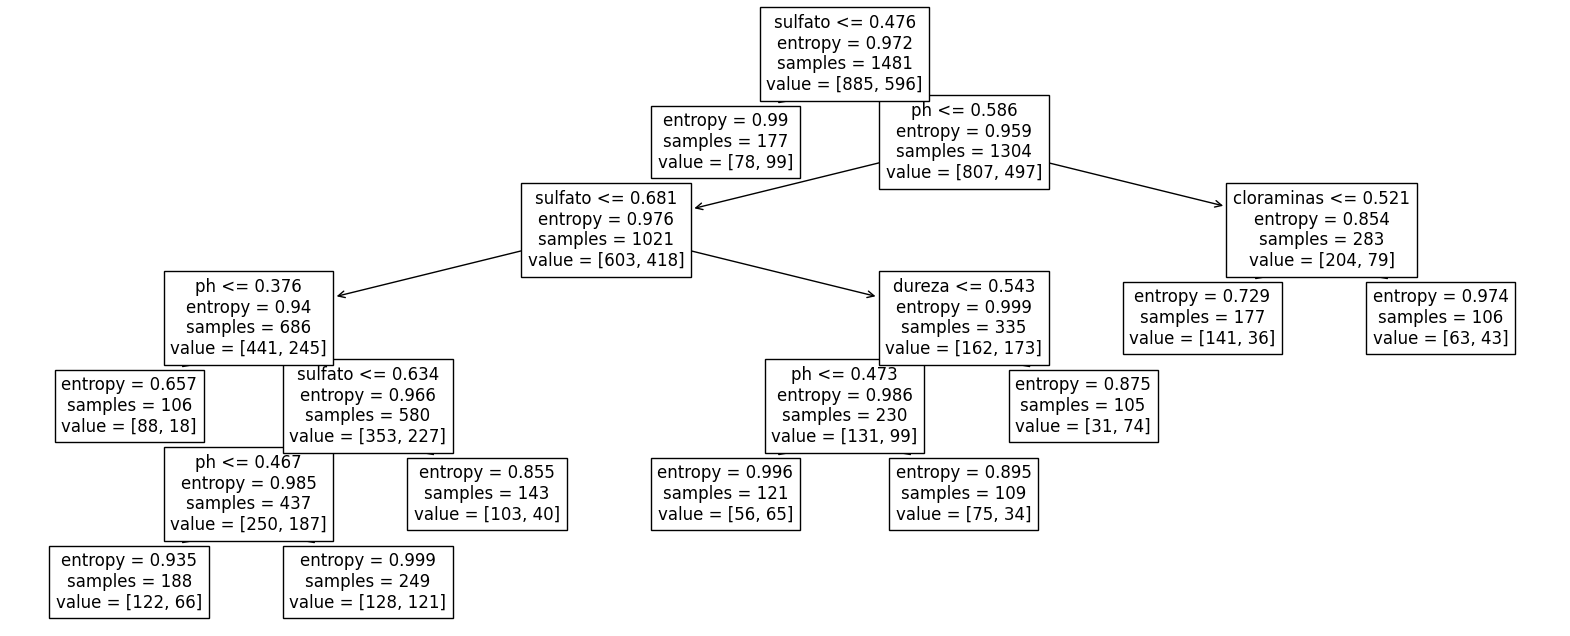

In [ ]:
fig = plt.figure(figsize=(20, 8))
tree.plot_tree(clf, feature_names=feature_cols)
plt.show()

In [ ]:
# Fazer previsões com os dados de teste normalizados
y_pred = clf.predict(X_test_scaled)
tree_pred = y_pred

# Avaliar a precisão do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy * 100:.2f}%')
#maior
# 66.93%
# clf = tree.DecisionTreeClassifier(
#     criterion='entropy',
#     splitter='best',
#     max_depth=6,
#     min_samples_split=0.1,
#     min_samples_leaf=105,
#     random_state=42
# )

Acurácia: 66.93%


Para treinar o modelo de forma mais eficiente primeiro definimos os parâmetros da função, sendo eles:
- N_neighbors
- Weights
- P

In [ ]:
kneigh = KNeighborsClassifier(
    n_neighbors=33,
    weights='distance',
    p=1,
)
# Treinar o modelo com os dados de treinamento normalizados
kneigh.fit(X_train_scaled, y_train)

KNeighborsClassifier(n_neighbors=33, p=1, weights='distance')

In [ ]:
# Fazer previsões com os dados de teste normalizados
y_pred = kneigh.predict(X_test_scaled)
kneigh_pred = y_pred

# Avaliar a precisão do modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia: {accuracy * 100:.2f}%')

Acurácia: 67.40%


In [ ]:
target_names = ["não potável", "potável"]
print("--------------------K-Neighbours---------------------")
print(classification_report(y_test, kneigh_pred, target_names=target_names))
cm = confusion_matrix(y_test, kneigh_pred)
print(f"true negative      {cm[0,0]}       false positive     {cm[0,1]}")
print(f"false negative     {cm[1,0]}       true positive      {cm[1,1]}")

--------------------K-Neighbours---------------------
              precision    recall  f1-score   support

 não potável       0.66      0.96      0.78       384
     potável       0.81      0.23      0.36       251

    accuracy                           0.67       635
   macro avg       0.73      0.60      0.57       635
weighted avg       0.72      0.67      0.61       635

true negative      370       false positive     14
false negative     193       true positive      58


In [ ]:
print("-------------------Árvore de decisão--------------------")
print(classification_report(y_test, tree_pred, target_names=target_names))
cm = confusion_matrix(y_test, tree_pred)
print(f"true negative      {cm[0,0]}       false positive     {cm[0,1]}")
print(f"false negative     {cm[1,0]}       true positive      {cm[1,1]}")

-------------------Árvore de decisão--------------------
              precision    recall  f1-score   support

 não potável       0.69      0.84      0.75       384
     potável       0.62      0.41      0.50       251

    accuracy                           0.67       635
   macro avg       0.65      0.63      0.63       635
weighted avg       0.66      0.67      0.65       635

true negative      321       false positive     63
false negative     147       true positive      104


In [ ]:
print(tree.export_text(clf, feature_names=feature_cols))

|--- sulfato <= 0.48
|   |--- class: 1
|--- sulfato >  0.48
|   |--- ph <= 0.59
|   |   |--- sulfato <= 0.68
|   |   |   |--- ph <= 0.38
|   |   |   |   |--- class: 0
|   |   |   |--- ph >  0.38
|   |   |   |   |--- sulfato <= 0.63
|   |   |   |   |   |--- ph <= 0.47
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- ph >  0.47
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- sulfato >  0.63
|   |   |   |   |   |--- class: 0
|   |   |--- sulfato >  0.68
|   |   |   |--- dureza <= 0.54
|   |   |   |   |--- ph <= 0.47
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- ph >  0.47
|   |   |   |   |   |--- class: 0
|   |   |   |--- dureza >  0.54
|   |   |   |   |--- class: 1
|   |--- ph >  0.59
|   |   |--- cloraminas <= 0.52
|   |   |   |--- class: 0
|   |   |--- cloraminas >  0.52
|   |   |   |--- class: 0

